## Final Project for Data 605 - Big data systems
- Name: Mohammed Ateeq Ur Rehman
- UID: 120872334

In [ ]:
%pip install petastorm pyarrow pandas matplotlib torch torchvision tensorflow fastparquet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import time
import pandas as pd
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import petastorm_bitcoin_processing_utils as utils
import pyarrow.parquet as pq

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from petastorm import make_batch_reader
from petastorm.unischema import Unischema, UnischemaField
from petastorm.codecs import ScalarCodec
from petastorm.etl.dataset_metadata import materialize_dataset
from petastorm import make_batch_reader


### Data Ingestion

In [3]:
output_dir = 'test_bitcoin_data'
os.makedirs(output_dir, exist_ok=True)

base_url = "https://api.coingecko.com/api/v3"
historical_data = []

In [4]:
# Parameters
interval_sec = 30  # every 30 seconds
duration_min = 1   # run for 1 minute
save_interval = 2  # save every 2 fetches

end_time = time.time() + duration_min * 60
fetch_count = 0
historical_data = []

output_file = os.path.join(output_dir, "bitcoin_price_data.csv")

while time.time() < end_time:
    try:
        price_data = utils.fetch_current_price(base_url)
        historical_data.append(price_data)
        fetch_count += 1
        print(f"Collected data at {price_data['timestamp']}")

        # Save to file every `save_interval` fetches
        if fetch_count % save_interval == 0:
            new_df = pd.DataFrame(historical_data)
            historical_data = []  # clear buffer after saving

            # Append to existing file or create new one
            if os.path.exists(output_file):
                new_df.to_csv(output_file, mode='a', header=False, index=False)
            else:
                new_df.to_csv(output_file, mode='w', header=True, index=False)

    except Exception as e:
        print(f"Error fetching data: {e}")
        break  # Use break instead of exit in notebooks/scripts

    time.sleep(interval_sec)
print("Data collection complete.")

Collected data at 2025-05-18T05:40:09.051093
Collected data at 2025-05-18T05:40:39.156265
Data collection complete.


### Data Storage

In [5]:
# 1. Load all price CSVs
csv_folder = r"test_bitcoin_data"
df = utils.load_all_csvs_from_folder(csv_folder)

# 2. Save to Parquet
parquet_path = "file:///test_bitcoin_data/parquet"
utils.save_to_parquet_arrow(df, parquet_path)

# 3. Load from Parquet and preview
batches = list(utils.load_from_parquet(input_dir='test_bitcoin_data\\parquet'))


Combined 2 CSV files.
======== Parquet file written to 
 e:\UMD\Data 605 - PCS2\Project\tutorials1\DATA605\Spring2025\projects\TutorTask188_Spring2025_Batch_Processing_of_Bitcoin_Price_Data_with_Petastorm​\docker_data605_style/test_bitcoin_data/parquet ==========
Loading data from file://e:/UMD/Data 605 - PCS2/Project/tutorials1/DATA605/Spring2025/projects/TutorTask188_Spring2025_Batch_Processing_of_Bitcoin_Price_Data_with_Petastorm​/docker_data605_style/test_bitcoin_data/parquet...


c:\Users\ateeq\anaconda3\Lib\site-packages\petastorm\fs_utils.py:88: FutureWarning: pyarrow.localfs is deprecated as of 2.0.0, please use pyarrow.fs.LocalFileSystem instead.
  self._filesystem = pyarrow.localfs
c:\Users\ateeq\anaconda3\Lib\site-packages\petastorm\etl\dataset_metadata.py:402: FutureWarning: Passing 'use_legacy_dataset=True' to get the legacy behaviour is deprecated as of pyarrow 11.0.0, and the legacy implementation will be removed in a future version. The legacy behaviour was still chosen because a deprecated 'pyarrow.filesystem' filesystem was specified (use the filesystems from pyarrow.fs instead).
  dataset = pq.ParquetDataset(path_or_paths, filesystem=fs, validate_schema=False, metadata_nthreads=10)
c:\Users\ateeq\anaconda3\Lib\site-packages\petastorm\etl\dataset_metadata.py:402: FutureWarning: Specifying the 'metadata_nthreads' argument is deprecated as of pyarrow 8.0.0, and the argument will be removed in a future version
  dataset = pq.ParquetDataset(path_or_pat

In [6]:
parquet_path = "test_bitcoin_data/parquet/data.parquet"
table = pq.read_table(parquet_path)
schema_columns = table.column_names
print("Columns:", table.column_names)


Columns: ['timestamp', 'price_usd', 'market_cap', 'price_change_24h']


In [7]:
for batch in batches[:1]:
    df = pd.DataFrame(batch)
    print(df.head())


                          0                           1    \
0  2025-05-17T18:47:14.689778  2025-05-17T18:47:44.810582   
1                    103057.0                    103057.0   
2        2047317305796.520752        2047317305796.520752   
3                   -0.394764                   -0.394764   

                          2                           3    \
0  2025-05-17T19:05:24.408553  2025-05-17T19:05:54.518471   
1                    103054.0                    103054.0   
2        2047160205666.818115        2047160205666.818115   
3                   -0.445364                   -0.445364   

                          4                           5    \
0  2025-05-17T21:49:08.839872  2025-05-17T21:49:38.944797   
1                    103268.0                    103268.0   
2        2051453556092.881104        2051453556092.881104   
3                    0.438986                    0.438986   

                          6                           7    \
0  2025-05-17T21:53:4

### Data Processing


=== Bitcoin Price Analysis Report ===
Time Period: 2024-05-17 00:00:00 to 2025-05-18 05:40:39.156265
Number of Data Points: 392

Price Statistics:
count       392.000000
mean      80835.044515
std       16710.253326
min       53948.750000
25%       64937.762500
50%       83586.895000
75%       96617.555000
max      106146.270000
Name: price_usd, dtype: float64

Latest Price: $104,003.00
24h Change: 0.93%


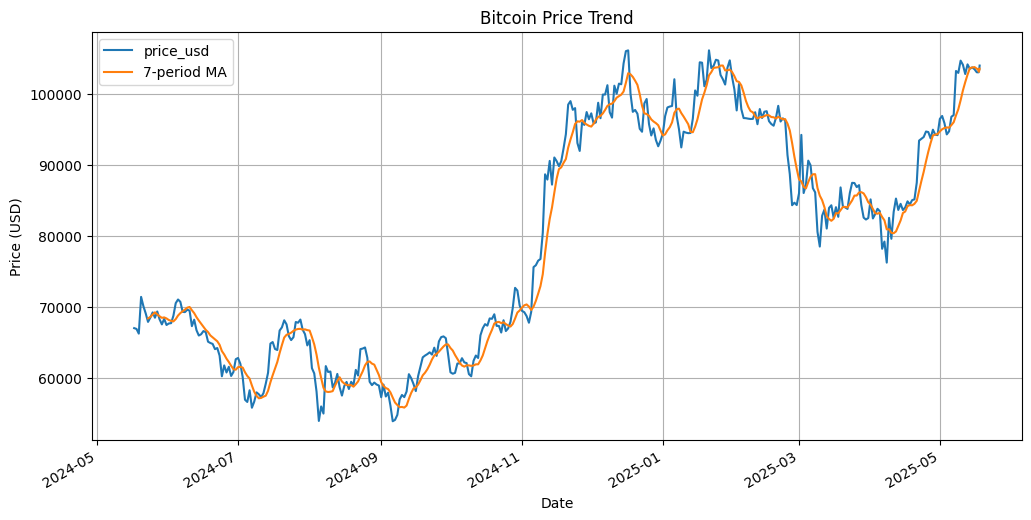

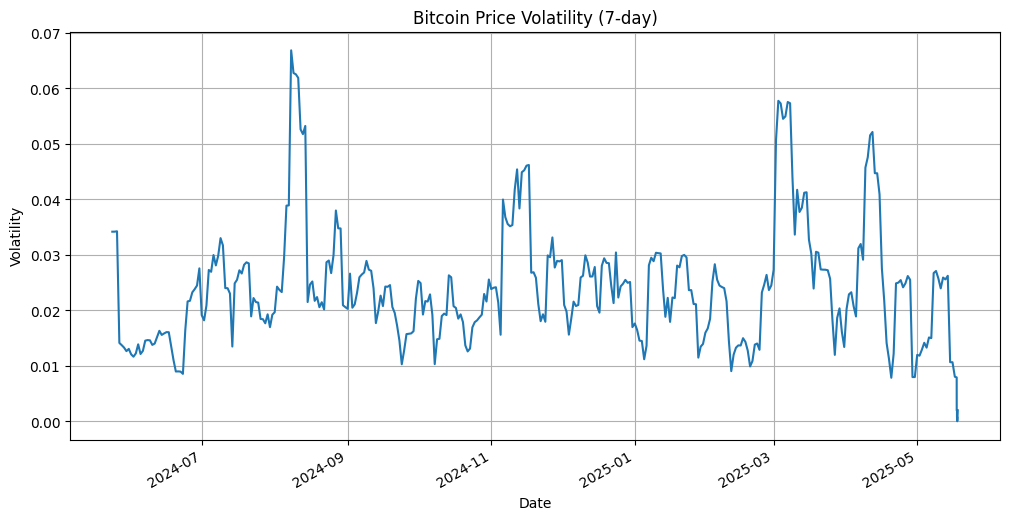

In [8]:
# Load → Prepare → Report
df = pd.read_parquet("test_bitcoin_data/parquet/data.parquet")
df = utils.prepare_bitcoin_df(df,)
utils.generate_report(df)


### ML Integration

In [10]:
# --- Global scaler ---
scaler = MinMaxScaler(feature_range=(0, 1))


# --- Load and Prepare Data ---
def load_and_prepare_data_from_parquet(file_path, look_back=10, test_size=0.2):
    df = pd.read_parquet(file_path)
    
    if 'price_usd' not in df.columns:
        raise ValueError("'price_usd' column is missing.")
    
    prices = df['price_usd'].values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(prices)

    X, y = [], []
    for i in range(look_back, len(scaled_data)):
        X.append(scaled_data[i - look_back:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    split = int(len(X) * (1 - test_size))
    # print(X[:split], X[split:], y[:split], y[split:], scaler)
    return X[:split], X[split:], y[:split], y[split:], scaler


# --- Build LSTM Model ---
def build_lstm_model(look_back):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(50, return_sequences=False),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model


# --- Train and Evaluate ---
def train_and_evaluate(data_path, look_back=10, epochs=50, batch_size=8):
    X_train, X_test, y_train, y_test, scaler = load_and_prepare_data_from_parquet(data_path, look_back)

    model = build_lstm_model(look_back)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
              validation_data=(X_test, y_test))

    train_predict = model.predict(X_train)
    test_predict = model.predict(X_test)

    # Inverse scaling
    train_predict = scaler.inverse_transform(train_predict)
    y_train_orig = scaler.inverse_transform([y_train])
    test_predict = scaler.inverse_transform(test_predict)
    y_test_orig = scaler.inverse_transform([y_test])

    # Evaluate RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train_orig[0], train_predict[:, 0]))
    test_rmse = np.sqrt(mean_squared_error(y_test_orig[0], test_predict[:, 0]))

    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")

        # === Plot Training Curves ===
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title('MAE Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model, train_predict, test_predict

In [11]:
import pandas as pd
df = pd.read_parquet("test_bitcoin_data/parquet")
print(f"Data has {len(df)} rows")


Data has 392 rows


Epoch 1/50
39/39 [==============================] - 5s 26ms/step - loss: 0.0624 - mae: 0.1772 - val_loss: 0.0079 - val_mae: 0.0722
Epoch 2/50
39/39 [==============================] - 0s 8ms/step - loss: 0.0113 - mae: 0.0820 - val_loss: 0.0047 - val_mae: 0.0571
Epoch 3/50
39/39 [==============================] - 0s 8ms/step - loss: 0.0097 - mae: 0.0754 - val_loss: 0.0053 - val_mae: 0.0612
Epoch 4/50
39/39 [==============================] - 0s 9ms/step - loss: 0.0110 - mae: 0.0784 - val_loss: 0.0054 - val_mae: 0.0627
Epoch 5/50
39/39 [==============================] - 0s 8ms/step - loss: 0.0101 - mae: 0.0781 - val_loss: 0.0055 - val_mae: 0.0625
Epoch 6/50
39/39 [==============================] - 0s 8ms/step - loss: 0.0094 - mae: 0.0747 - val_loss: 0.0036 - val_mae: 0.0479
Epoch 7/50
39/39 [==============================] - 0s 7ms/step - loss: 0.0096 - mae: 0.0778 - val_loss: 0.0048 - val_mae: 0.0583
Epoch 8/50
39/39 [==============================] - 0s 7ms/step - loss: 0.0095 - mae: 0.0

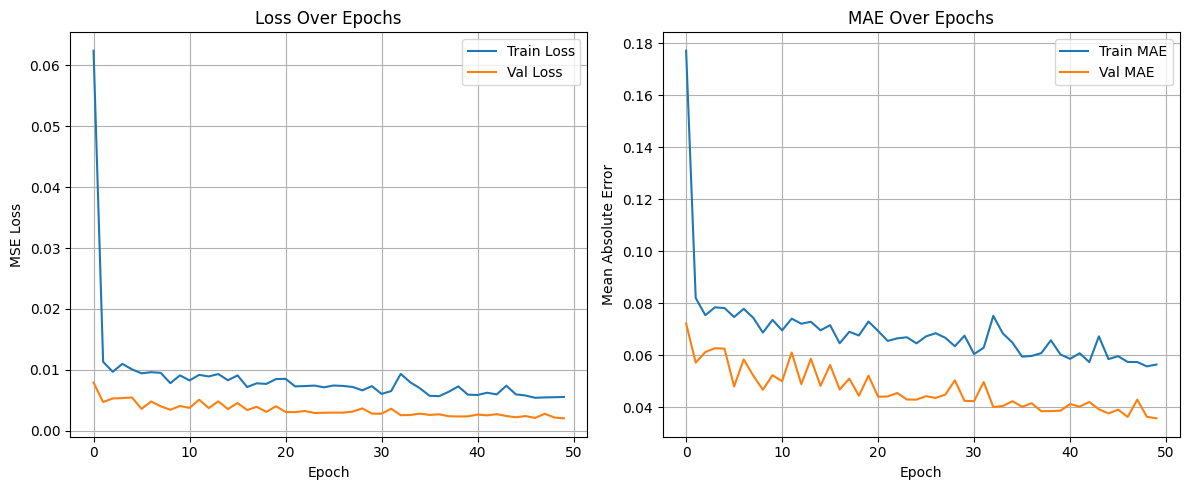

In [12]:
data_path = "test_bitcoin_data/parquet"
model, train_pred, test_pred = train_and_evaluate(data_path, look_back=10, epochs=50, batch_size=8)